In [89]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Dict, List

In [90]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guess: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int
    max_attempts: int
    secret: int
    current_guess: int
    result: str

In [ ]:
def setup(state: AgentState) -> dict:
    state.setdefault("lower_bound", 1)
    state.setdefault("upper_bound", 20)
    state.setdefault("attempts", 0)
    state.setdefault("guess", [])
    state.setdefault("max_attempts", 7)
    state.setdefault("secret", state.get("secret",  None))  # optional
    return state

def guess(state: AgentState) -> AgentState:
    print(">>> guess running")
    state.setdefault("guess", [])
    current = (state["lower_bound"] + state["upper_bound"]) // 2
    state["current_guess"] = current
    state["guess"].append(current)
    print("Current guess:", current)
    state["attempts"] = state.get("attempts",0) + 1
    return state

def hint(state: AgentState) -> AgentState:
    print(">>> hint running; state keys:", list(state.keys()))
    g = state.get("current_guess")
    print("Current guess:", g)
    if g is None:
        raise KeyError("current_guess missing — guess did not run")
    s = state["secret"]
    if g == s:
        state["hint"] = "correct"
    elif g < s:
        state["hint"] = "higher"
    else:
        state["hint"] = "lower"
    return state

def update_bounds(state: AgentState) -> AgentState:
    g = state["current_guess"]
    if state["hint"] == "higher":
        state["lower_bound"] = max(state["lower_bound"], g + 1)
    elif state["hint"] == "lower":
        state["upper_bound"] = min(state["upper_bound"], g - 1)
    return state

def check_finish(state: AgentState) -> str:
    if state.get("hint") == "correct" or state.get("attempts",0) >= state.get("max_attempts",7):
        return "finish"
    return "continue"

def finish(state: AgentState) -> AgentState:
    if state.get("hint") == "correct":
        state["result"] = f"Guessed {state['current_guess']} in {state['attempts']} attempts"
    else:
        state["result"] = "Failed to guess within max attempts"
    return state


In [97]:
graph = StateGraph(AgentState)
# nodes
graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint", hint)
graph.add_node("update_bounds", update_bounds)
graph.add_node("finish", finish)

# linear flow
graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_edge("hint", "update_bounds")
graph.add_edge("update_bounds", "check_finish")

# conditional branching from router
# instead of graph.add_node("check_finish", check_finish)
graph.add_node("check_finish", lambda state: state)   # router node returns state
graph.add_conditional_edges("check_finish", check_finish, {
    "continue": "guess",
    "finish": "finish",
})

# finish -> END
graph.add_edge("finish", END)

app = graph.compile()

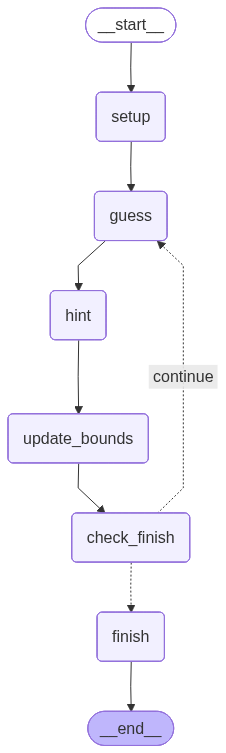

In [98]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state1: AgentState = {
    "player_name": "Alice",
    "target_number": 0,  # not used in this implementation
    "guess": [],
    "attempts": 0,
    "hint": "",
    "lower_bound": 1,
    "upper_bound": 20,
    "max_attempts": 7,
    "secret": 10
}
initial_state2: AgentState = {
    "player_name": "Bob",
    "target_number": 0,  # not used in this implementation
    "guess": [],
    "attempts": 0,
    "hint": "",
    "lower_bound": 1,
    "upper_bound": 20,
    "max_attempts": 7,
    "secret": 25
}

print(app.invoke(initial_state1)["result"])  # Should print success message
print(app.invoke(initial_state2)["result"])  # Should print failure message
